In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

In [5]:
flights = pd.read_csv("C:/Users/achat/Desktop/githubproj/team2/csvFile/flight_delays.csv")
flights

,FlightID,Airline,FlightNumber,Origin,Destination,ScheduledDeparture,ActualDeparture,ScheduledArrival,ActualArrival,DelayMinutes,DelayReason,Cancelled,Diverted,AircraftType,TailNumber,Distance
0,1,United,4558,ORD,MIA,2024-09-01 08:11,2024-09-01 08:30,2024-09-01 12:11,2024-09-01 12:19,8,Weather,True,False,Boeing 737,N71066,1031
1,2,Delta,8021,LAX,MIA,2024-09-01 10:25,2024-09-01 10:41,2024-09-01 13:25,2024-09-01 13:27,2,Air Traffic Control,True,True,Airbus A320,N22657,1006
2,3,Southwest,7520,DFW,SFO,2024-09-01 16:53,2024-09-01 17:05,2024-09-01 17:53,2024-09-01 18:07,14,Weather,True,True,Boeing 737,N95611,2980
3,4,Delta,2046,ORD,BOS,2024-09-01 14:44,2024-09-01 15:04,2024-09-01 18:44,2024-09-01 18:34,-10,NaN,False,False,Boeing 777,N90029,1408
4,5,Delta,6049,LAX,SEA,2024-09-01 01:51,2024-09-01 02:08,2024-09-01 05:51,2024-09-01 06:15,24,Air Traffic Control,False,True,Boeing 737,N27417,2298
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1747622,1747623,United,4145,DFW,MIA,2024-09-01 12:46,2024-09-01 12:54,2024-09-01 17:46,2024-09-01 17:41,-5,NaN,False,True,Boeing 737,N19796,2396
1747623,1747624,United,2155,ATL,SEA,2024-09-01 20:43,2024-09-01 20:54,2024-09-01 21:43,2024-09-01 22:03,20,Weather,True,False,Boeing 777,N68154,2185
1747624,1747625,Delta,4878,JFK,SFO,2024-09-01 03:26,2024-09-01 03:47,2024-09-01 06:26,2024-09-01 06:20,-6,NaN,False,False,Boeing 777,N18964,361
1747625,1747626,Delta,2940,JFK,SEA,2024-09-01 08:04,2024-09-01 08:07,2024-09-01 13:04,2024-09-01 13:20,16,Maintenance,False,True,Airbus A320,N94591,2793


In [8]:
flights.describe()

,FlightID,FlightNumber,DelayMinutes,Distance
count,1.747627e+06,1.747627e+06,1.747627e+06,1.747627e+06
mean,8.738140e+05,5.001158e+03,9.999179e+00,1.549936e+03
std,5.044966e+05,2.885822e+03,1.183112e+01,8.368681e+02
min,1.000000e+00,1.000000e+00,-1.000000e+01,1.000000e+02
25%,4.369075e+05,2.503000e+03,0.000000e+00,8.250000e+02
50%,8.738140e+05,5.002000e+03,1.000000e+01,1.551000e+03
75%,1.310720e+06,7.499000e+03,2.000000e+01,2.274000e+03
max,1.747627e+06,9.999000e+03,3.000000e+01,3.000000e+03


In [9]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1747627 entries, 0 to 1747626
Data columns (total 16 columns):
 #   Column              Dtype         
---  ------              -----         
 0   FlightID            int64         
 1   Airline             object        
 2   FlightNumber        int64         
 3   Origin              object        
 4   Destination         object        
 5   ScheduledDeparture  datetime64[ns]
 6   ActualDeparture     datetime64[ns]
 7   ScheduledArrival    datetime64[ns]
 8   ActualArrival       datetime64[ns]
 9   DelayMinutes        int64         
 10  DelayReason         object        
 11  Cancelled           bool          
 12  Diverted            bool          
 13  AircraftType        object        
 14  TailNumber          object        
 15  Distance            int64         
dtypes: bool(2), datetime64[ns](4), int64(4), object(6)
memory usage: 190.0+ MB


In [10]:
flights.isnull().sum()

FlightID                   0
Airline                    0
FlightNumber               0
Origin                     0
Destination                0
ScheduledDeparture         0
ActualDeparture            0
ScheduledArrival           0
ActualArrival              0
DelayMinutes               0
DelayReason           468873
Cancelled                  0
Diverted                   0
AircraftType               0
TailNumber                 0
Distance                   0
dtype: int64

In [11]:
flights.fillna("No Delay Reason", inplace=True)

In [12]:
flights.head(100)

,FlightID,Airline,FlightNumber,Origin,Destination,ScheduledDeparture,ActualDeparture,ScheduledArrival,ActualArrival,DelayMinutes,DelayReason,Cancelled,Diverted,AircraftType,TailNumber,Distance
0,1,United,4558,ORD,MIA,2024-09-01 08:11:00,2024-09-01 08:30:00,2024-09-01 12:11:00,2024-09-01 12:19:00,8,Weather,True,False,Boeing 737,N71066,1031
1,2,Delta,8021,LAX,MIA,2024-09-01 10:25:00,2024-09-01 10:41:00,2024-09-01 13:25:00,2024-09-01 13:27:00,2,Air Traffic Control,True,True,Airbus A320,N22657,1006
2,3,Southwest,7520,DFW,SFO,2024-09-01 16:53:00,2024-09-01 17:05:00,2024-09-01 17:53:00,2024-09-01 18:07:00,14,Weather,True,True,Boeing 737,N95611,2980
3,4,Delta,2046,ORD,BOS,2024-09-01 14:44:00,2024-09-01 15:04:00,2024-09-01 18:44:00,2024-09-01 18:34:00,-10,No Delay Reason,False,False,Boeing 777,N90029,1408
4,5,Delta,6049,LAX,SEA,2024-09-01 01:51:00,2024-09-01 02:08:00,2024-09-01 05:51:00,2024-09-01 06:15:00,24,Air Traffic Control,False,True,Boeing 737,N27417,2298
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,Delta,8531,JFK,BOS,2024-09-01 00:35:00,2024-09-01 00:50:00,2024-09-01 02:35:00,2024-09-01 02:49:00,14,Air Traffic Control,True,True,Boeing 777,N49477,794
96,97,American Airlines,1655,ATL,SFO,2024-09-01 11:57:00,2024-09-01 12:19:00,2024-09-01 17:57:00,2024-09-01 18:25:00,28,Weather,True,True,Airbus A320,N17550,2948
97,98,United,8925,ATL,JFK,2024-09-01 22:50:00,2024-09-01 22:55:00,2024-09-02 03:50:00,2024-09-02 04:09:00,19,Weather,True,True,Boeing 777,N44017,1436
98,99,Delta,5930,LAX,SEA,2024-09-01 08:47:00,2024-09-01 08:52:00,2024-09-01 11:47:00,2024-09-01 12:08:00,21,Maintenance,False,False,Boeing 777,N70967,2608


In [13]:
flights['ScheduledDeparture'] = pd.to_datetime(flights['ScheduledDeparture'])
flights['ActualDeparture'] = pd.to_datetime(flights['ActualDeparture'])
flights['ScheduledArrival'] = pd.to_datetime(flights['ScheduledArrival'])
flights['ActualArrival'] = pd.to_datetime(flights['ActualArrival'])

In [14]:
flights.head(5)

,FlightID,Airline,FlightNumber,Origin,Destination,ScheduledDeparture,ActualDeparture,ScheduledArrival,ActualArrival,DelayMinutes,DelayReason,Cancelled,Diverted,AircraftType,TailNumber,Distance
0,1,United,4558,ORD,MIA,2024-09-01 08:11:00,2024-09-01 08:30:00,2024-09-01 12:11:00,2024-09-01 12:19:00,8,Weather,True,False,Boeing 737,N71066,1031
1,2,Delta,8021,LAX,MIA,2024-09-01 10:25:00,2024-09-01 10:41:00,2024-09-01 13:25:00,2024-09-01 13:27:00,2,Air Traffic Control,True,True,Airbus A320,N22657,1006
2,3,Southwest,7520,DFW,SFO,2024-09-01 16:53:00,2024-09-01 17:05:00,2024-09-01 17:53:00,2024-09-01 18:07:00,14,Weather,True,True,Boeing 737,N95611,2980
3,4,Delta,2046,ORD,BOS,2024-09-01 14:44:00,2024-09-01 15:04:00,2024-09-01 18:44:00,2024-09-01 18:34:00,-10,No Delay Reason,False,False,Boeing 777,N90029,1408
4,5,Delta,6049,LAX,SEA,2024-09-01 01:51:00,2024-09-01 02:08:00,2024-09-01 05:51:00,2024-09-01 06:15:00,24,Air Traffic Control,False,True,Boeing 737,N27417,2298


In [15]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1747627 entries, 0 to 1747626
Data columns (total 16 columns):
 #   Column              Dtype         
---  ------              -----         
 0   FlightID            int64         
 1   Airline             object        
 2   FlightNumber        int64         
 3   Origin              object        
 4   Destination         object        
 5   ScheduledDeparture  datetime64[ns]
 6   ActualDeparture     datetime64[ns]
 7   ScheduledArrival    datetime64[ns]
 8   ActualArrival       datetime64[ns]
 9   DelayMinutes        int64         
 10  DelayReason         object        
 11  Cancelled           bool          
 12  Diverted            bool          
 13  AircraftType        object        
 14  TailNumber          object        
 15  Distance            int64         
dtypes: bool(2), datetime64[ns](4), int64(4), object(6)
memory usage: 190.0+ MB


In [18]:
flights["DepartureDiff"]=  flights['ActualDeparture'] - flights['ScheduledDeparture'] 
flights['DepartureDiff'] = flights['DepartureDiff'] / pd.Timedelta(minutes=1)

In [19]:
flights.head()

,FlightID,Airline,FlightNumber,Origin,Destination,ScheduledDeparture,ActualDeparture,ScheduledArrival,ActualArrival,DelayMinutes,DelayReason,Cancelled,Diverted,AircraftType,TailNumber,Distance,DepartureDiff
0,1,United,4558,ORD,MIA,2024-09-01 08:11:00,2024-09-01 08:30:00,2024-09-01 12:11:00,2024-09-01 12:19:00,8,Weather,True,False,Boeing 737,N71066,1031,19.0
1,2,Delta,8021,LAX,MIA,2024-09-01 10:25:00,2024-09-01 10:41:00,2024-09-01 13:25:00,2024-09-01 13:27:00,2,Air Traffic Control,True,True,Airbus A320,N22657,1006,16.0
2,3,Southwest,7520,DFW,SFO,2024-09-01 16:53:00,2024-09-01 17:05:00,2024-09-01 17:53:00,2024-09-01 18:07:00,14,Weather,True,True,Boeing 737,N95611,2980,12.0
3,4,Delta,2046,ORD,BOS,2024-09-01 14:44:00,2024-09-01 15:04:00,2024-09-01 18:44:00,2024-09-01 18:34:00,-10,No Delay Reason,False,False,Boeing 777,N90029,1408,20.0
4,5,Delta,6049,LAX,SEA,2024-09-01 01:51:00,2024-09-01 02:08:00,2024-09-01 05:51:00,2024-09-01 06:15:00,24,Air Traffic Control,False,True,Boeing 737,N27417,2298,17.0


In [22]:
flights["ScheduledDuration"] = flights["ScheduledArrival"] - flights["ScheduledDeparture"]
flights["ActualDuration"] = flights["ActualArrival"] - flights["ActualDeparture"]
flights.head()

,FlightID,Airline,FlightNumber,Origin,Destination,ScheduledDeparture,ActualDeparture,ScheduledArrival,ActualArrival,DelayMinutes,DelayReason,Cancelled,Diverted,AircraftType,TailNumber,Distance,DepartureDiff,ScheduledDuration,ActualDuration
0,1,United,4558,ORD,MIA,2024-09-01 08:11:00,2024-09-01 08:30:00,2024-09-01 12:11:00,2024-09-01 12:19:00,8,Weather,True,False,Boeing 737,N71066,1031,19.0,0 days 04:00:00,0 days 03:49:00
1,2,Delta,8021,LAX,MIA,2024-09-01 10:25:00,2024-09-01 10:41:00,2024-09-01 13:25:00,2024-09-01 13:27:00,2,Air Traffic Control,True,True,Airbus A320,N22657,1006,16.0,0 days 03:00:00,0 days 02:46:00
2,3,Southwest,7520,DFW,SFO,2024-09-01 16:53:00,2024-09-01 17:05:00,2024-09-01 17:53:00,2024-09-01 18:07:00,14,Weather,True,True,Boeing 737,N95611,2980,12.0,0 days 01:00:00,0 days 01:02:00
3,4,Delta,2046,ORD,BOS,2024-09-01 14:44:00,2024-09-01 15:04:00,2024-09-01 18:44:00,2024-09-01 18:34:00,-10,No Delay Reason,False,False,Boeing 777,N90029,1408,20.0,0 days 04:00:00,0 days 03:30:00
4,5,Delta,6049,LAX,SEA,2024-09-01 01:51:00,2024-09-01 02:08:00,2024-09-01 05:51:00,2024-09-01 06:15:00,24,Air Traffic Control,False,True,Boeing 737,N27417,2298,17.0,0 days 04:00:00,0 days 04:07:00


In [25]:
flights["DepartureDelay"] = ((flights["ActualDeparture"] - flights["ScheduledDeparture"]).dt.total_seconds() / 60).astype(int)
flights["ArrivalDelay"]   =((flights["ActualArrival"]   - flights["ScheduledArrival"]).dt.total_seconds() / 60).astype(int)
flights.head()

,FlightID,Airline,FlightNumber,Origin,Destination,ScheduledDeparture,ActualDeparture,ScheduledArrival,ActualArrival,DelayMinutes,...,Cancelled,Diverted,AircraftType,TailNumber,Distance,DepartureDiff,ScheduledDuration,ActualDuration,DepartureDelay,ArrivalDelay
0,1,United,4558,ORD,MIA,2024-09-01 08:11:00,2024-09-01 08:30:00,2024-09-01 12:11:00,2024-09-01 12:19:00,8,...,True,False,Boeing 737,N71066,1031,19.0,0 days 04:00:00,0 days 03:49:00,19,8
1,2,Delta,8021,LAX,MIA,2024-09-01 10:25:00,2024-09-01 10:41:00,2024-09-01 13:25:00,2024-09-01 13:27:00,2,...,True,True,Airbus A320,N22657,1006,16.0,0 days 03:00:00,0 days 02:46:00,16,2
2,3,Southwest,7520,DFW,SFO,2024-09-01 16:53:00,2024-09-01 17:05:00,2024-09-01 17:53:00,2024-09-01 18:07:00,14,...,True,True,Boeing 737,N95611,2980,12.0,0 days 01:00:00,0 days 01:02:00,12,14
3,4,Delta,2046,ORD,BOS,2024-09-01 14:44:00,2024-09-01 15:04:00,2024-09-01 18:44:00,2024-09-01 18:34:00,-10,...,False,False,Boeing 777,N90029,1408,20.0,0 days 04:00:00,0 days 03:30:00,20,-10
4,5,Delta,6049,LAX,SEA,2024-09-01 01:51:00,2024-09-01 02:08:00,2024-09-01 05:51:00,2024-09-01 06:15:00,24,...,False,True,Boeing 737,N27417,2298,17.0,0 days 04:00:00,0 days 04:07:00,17,24


In [26]:
most_common_reason = flights["DelayReason"].mode()[0]
print(most_common_reason)

No Delay Reason


In [28]:
reason_counts = flights["DelayReason"].value_counts()
print(reason_counts)


No Delay Reason        468873
Air Traffic Control    426488
Maintenance            426168
Weather                426098
Name: DelayReason, dtype: int64


                       most_common   count
Airline                                   
American Airlines  No Delay Reason  117579
Delta              No Delay Reason  117022
Southwest          No Delay Reason  117415
United             No Delay Reason  116857


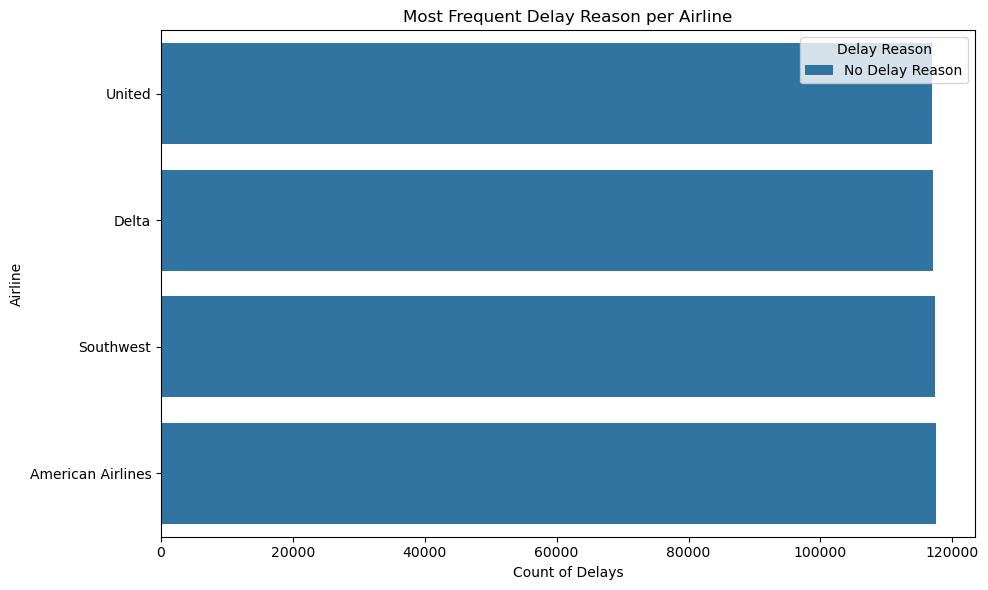

In [45]:
reason_by_airline = flights.groupby("Airline")["DelayReason"].agg(
    most_common=lambda s: s.value_counts().idxmax(),
    count=lambda s: s.value_counts().max()
)

print(reason_by_airline)
reason_by_airline_plot = reason_by_airline.reset_index()
reason_by_airline_plot = reason_by_airline_plot.sort_values(by="count", ascending=True)

plt.figure(figsize=(10,6))

sns.barplot(
    data=reason_by_airline_plot,
    y="Airline",
    x="count",
    hue="most_common",
    dodge=False
)

plt.title("Most Frequent Delay Reason per Airline")
plt.xlabel("Count of Delays")
plt.ylabel("Airline")
plt.legend(title="Delay Reason")
plt.tight_layout()
plt.show()

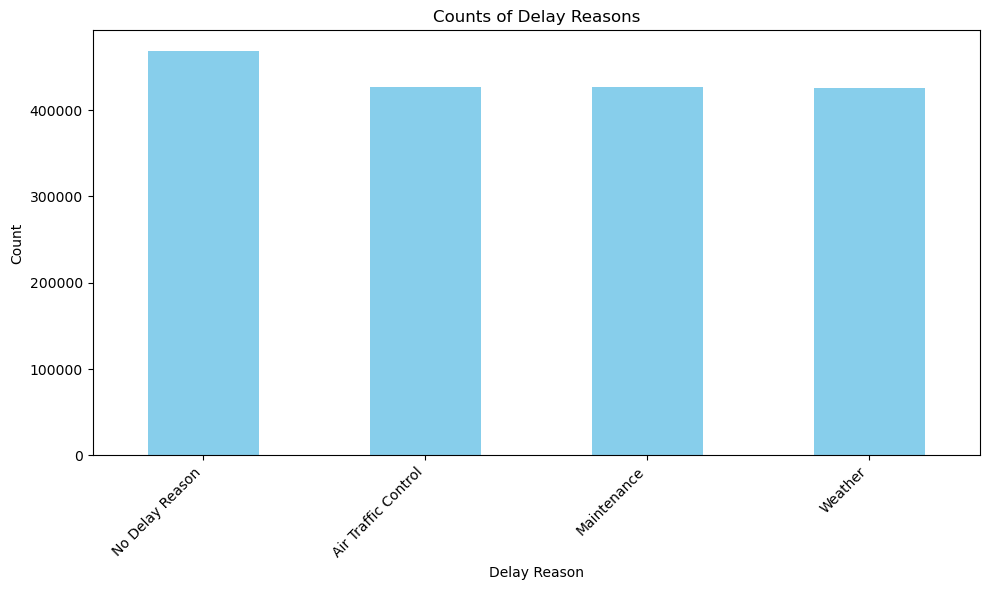

In [38]:
# Create a bar plot
plt.figure(figsize=(10,6))
reason_counts.plot(kind='bar', color='skyblue')
plt.title('Counts of Delay Reasons')
plt.xlabel('Delay Reason')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')  # rotate x labels if needed
plt.tight_layout()  # adjusts layout to prevent label cut-off
plt.show()

  Origin  DelayMinutes
2    JFK     10.008262
0    ATL     10.007840
4    ORD     10.003008
3    LAX      9.994706
1    DFW      9.982051


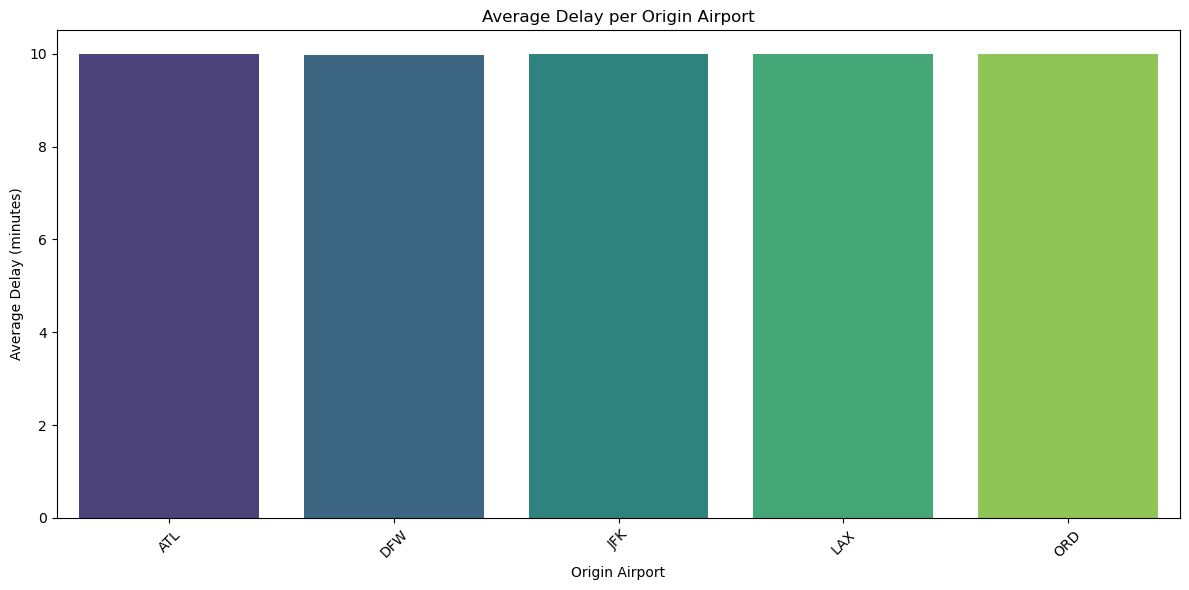

In [63]:
avg_delay_origin = flights.groupby('Origin')['DelayMinutes'].mean().reset_index()
avg_delay_origin_sorted = avg_delay_origin.sort_values(by='DelayMinutes', ascending=False)
print(avg_delay_origin_sorted)
plt.figure(figsize=(12,6))
sns.barplot(
    data=avg_delay_origin,
    x='Origin',
    y='DelayMinutes',
    hue='Origin',       # assign x to hue
    dodge=False,
    palette='viridis',
    legend=False         # disable legend since hue is same as x
)
plt.xticks(rotation=45)
plt.title('Average Delay per Origin Airport')
plt.ylabel('Average Delay (minutes)')
plt.xlabel('Origin Airport')
plt.tight_layout()
plt.show()

In [52]:
avg_delay_destination = flights.groupby('Destination')['DelayMinutes'].mean().reset_index()
avg_delay_destination = avg_delay_destination.rename(columns={'DelayMinutes': 'AvgDelayMinutes'})
avg_delay_destination

,Destination,AvgDelayMinutes
0,BOS,9.989404
1,JFK,9.978798
2,MIA,10.010067
3,SEA,9.998015
4,SFO,10.019601
